In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

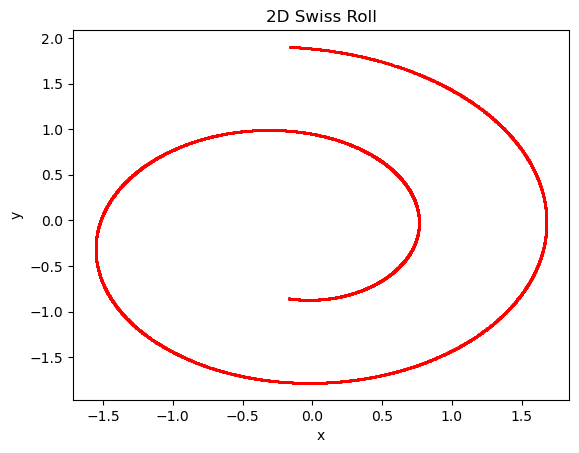

In [4]:
X,t = make_swiss_roll(n_samples=10000, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

plt.scatter(X[:,0], X[:,1], s=1, color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Swiss Roll")
X = torch.tensor(X, dtype=torch.float32)

In [5]:
def train_model(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  sigma = 0.2,
  num_epochs = 500      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(2,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    
    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for batch in loader:

            x = batch[0]
            
            eps = torch.randn_like(x)
            
            x_noisy = x + sigma*eps
            
            score_pred = model(x_noisy)

            target = -eps/sigma

            loss = ((score_pred-target)**2).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return model, loss_history    


In [21]:

results_opt_compare = {}

for opt in ["SGD","Adam"]:

    model,losses = train_model(optimizer_name=opt)
    results_opt_compare[opt] = losses

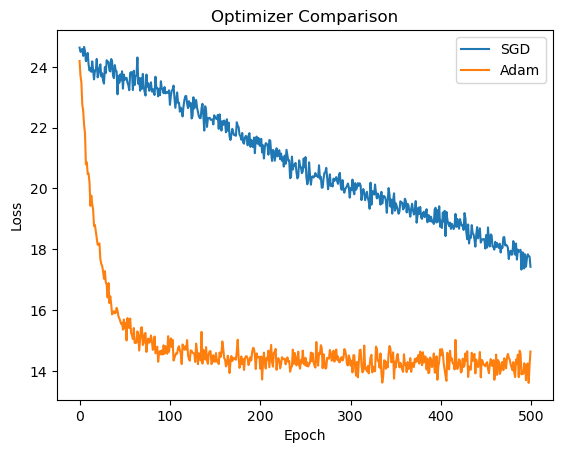

In [22]:
plt.figure()

for name, losses in results_opt_compare.items():

    plt.plot(
        losses,
        label=name
    )

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")

plt.show()

In [23]:
results_batch_size = {}

for  bs in [25, 50, 100, 200]:
    model, losses = train_model(batch_size=bs)

    results_batch_size[f"bs={bs}"] = losses

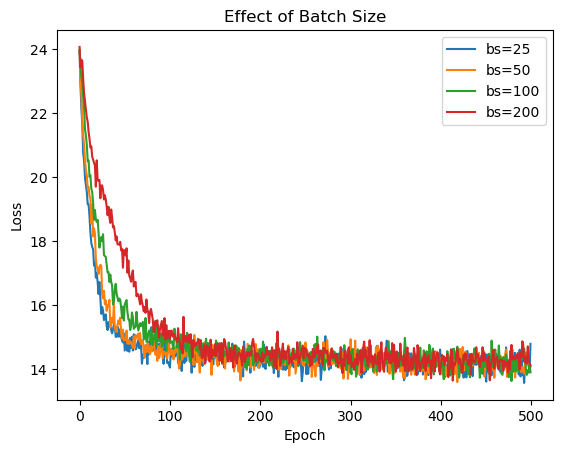

In [26]:
plt.figure()

for name, losses in results_batch_size.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Batch Size")

plt.legend()
plt.show()

In [27]:
results_width_effect = {}

for width in [32, 64, 128, 256]:

    model, losses = train_model(width=width)

    results_width_effect[f"width={width}"] = losses
    

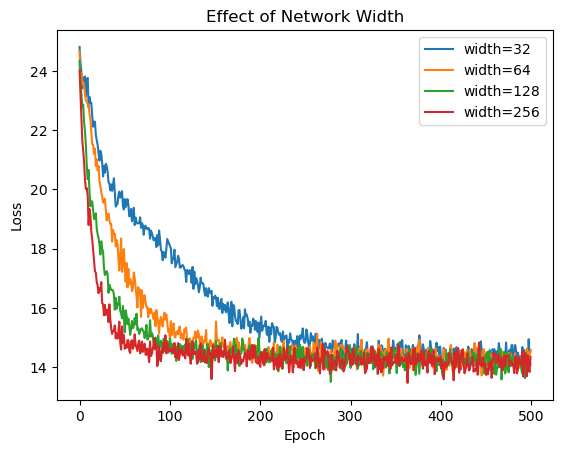

In [28]:
plt.figure()

for name, losses in results_width_effect.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Network Width")

plt.legend()
plt.show()

In [33]:
results_depth_effect = {}

for depth in [2, 3, 4]:

    model, losses = train_model(depth=depth)

    results_depth_effect[f"depth={depth}"] = losses

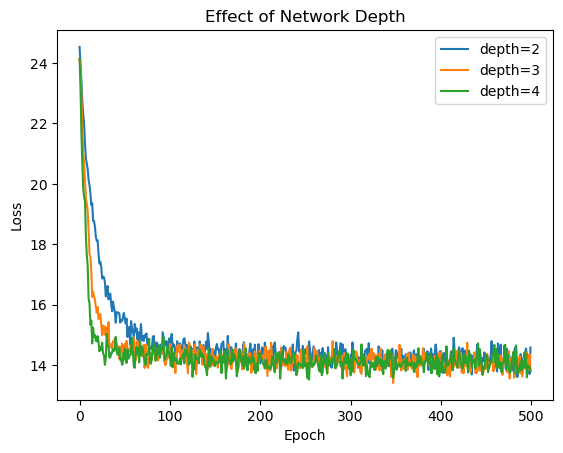

In [34]:
plt.figure()

for name, losses in results_depth_effect.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Network Depth")

plt.legend()
plt.show()

In [37]:
results_learn_rate_effect = {}

for lr in [5e-4, 5e-3, 5e-2]:

    model, losses = train_model(lr=lr)

    results_learn_rate_effect[f"LR={lr}"] = losses

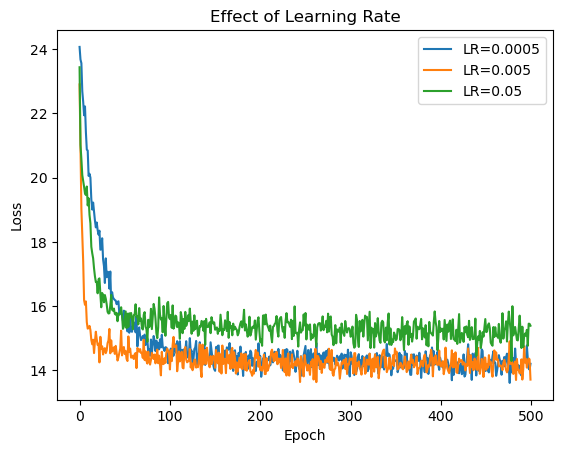

In [38]:
plt.figure()

for name, losses in results_learn_rate_effect.items():

    plt.plot(losses,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")

plt.legend()
plt.show()

In [7]:
results_sigma = {}

for  sig in [0.05, 0.15, 0.5]:
    model, losses = train_model(sigma=sig, num_epochs=5000)

    results_sigma[sig] = model

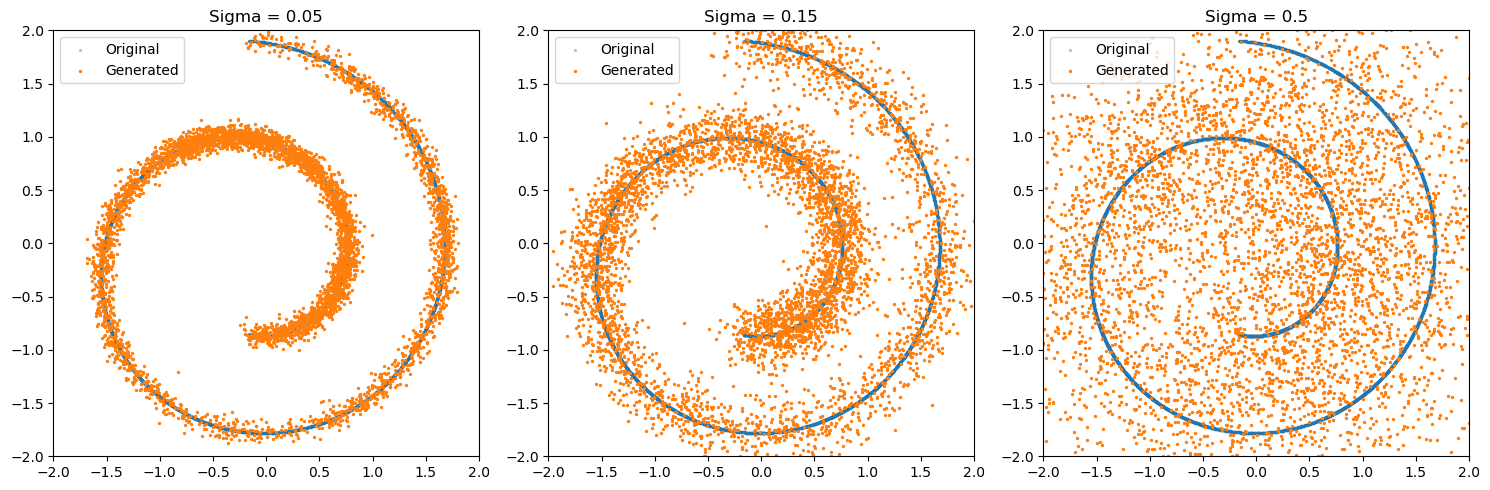

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

eta = 0.001
n_steps = 500

for ax, (sig, model) in zip(axes, results_sigma.items()):

    x = torch.randn(5000, 2)

    for _ in range(n_steps):
        score = model(x)
        noise = torch.randn_like(x)

        x = x + eta * score + np.sqrt(2 * eta) * noise

    samples = x.detach().numpy()

    
    ax.scatter(X[:,0], X[:,1],
               s=2, alpha=0.3,
               label="Original")

  
    ax.scatter(samples[:,0], samples[:,1],
               s=2,
               label="Generated")

    ax.set_title(f"Sigma = {sig}")
    ax.legend()
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)

plt.tight_layout()
plt.show()